# Librerías

In [48]:
import numpy as np
import pandas as pd  # Cambiado a pd, que es el estándar para manipulación de datos
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf # Corregido de 'ft' a 'tf'

# Herramientas para procesar texto (NLP)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Arquitectura del modelo
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, SimpleRNN, LSTM, Input 

# Optimizador (aquí es donde puedes aplicar el Gradient Clipping que vimos)
from tensorflow.keras.optimizers import Adam

# --- NOTAS SOBRE LAS CAPAS IMPORTADAS ---

# SimpleRNN: Es la red de Elman. Memoria corta, propensa a Vanishing Gradient.
# LSTM: La que usa Cell State y Gates (Forget, Input, Output) para memoria larga.
# Embedding: Transforma índices de palabras en vectores densos (indispensable para tus quejas).
# Dense: Capa totalmente conectada para la clasificación final (Softmax o Sigmoid).
# Adam: El optimizador que ajustará los pesos basándose en el error.

Fijar semillas de aleatoriedad

In [4]:
np.random.seed(42)
tf.random.set_seed(42)

# Funciones

In [92]:
# Función para crear una frase sintética que simule un lenguaje natural
def construir_frase(inicio, sujeto):
    # Definimos la longitud variable de la frase para que el modelo (como una LSTM)
    # aprenda a manejar secuencias de distintos tamaños.
    num_fragmentos = random.randint(4, 6)
    
    # Seleccionamos palabras de relleno ('ruido') de forma aleatoria sin repetir en la misma frase.
    # Esto ayuda a que el modelo no se aprenda una frase de memoria, sino los patrones.
    ruido = random.sample(fragmentos_ruido, num_fragmentos)
    
    # Construcción final de la cadena usando f-strings:
    # Combina el sentimiento inicial, el sujeto, el cuerpo de la frase y un final neutral.
    frase = f"{inicio} {sujeto} " + " ".join(ruido) + " " + random.choice(cierres_neutrales)
    return frase


def graficar_resultados(history, titulo):
    # Creamos una figura con dos subgráficas (Precision y Pérdida)
    plt.figure(figsize=(12, 5))

    # 1. Gráfica de Precisión (Accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Entrenamiento', color='blue', linestyle='--')
    plt.plot(history.history['val_accuracy'], label='Validación', color='red')
    plt.title(f'Precisión - {titulo}')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # 2. Gráfica de Pérdida (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entrenamiento', color='blue', linestyle='--')
    plt.plot(history.history['val_loss'], label='Validación', color='red')
    plt.title(f'Pérdida - {titulo}')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Modelo

In [7]:
inicios_positivos = [
    "el excelente","la brillante",    "el destacado",    "la maravillosa", "el gran",    "la experta",    "la espectacular"
]
inicios_negativos = [
    "el terrible",    "la pesima", "el deficiente",    "la desastrosa",   "el peor",    "la inexperta", 
    "el horrible",    "la frustrante",    "el ineficiente"
]
sujetos = [
    "profesor", "alumna", "investigador",    "ingeniera", "medico",    "estudiante"
]

fragmentos_ruido = [
    "que durante la extensa clase de inteligencia artificial reviso varios ejemplos",
    "mientras los estudiantes tomaban notas sin parar en sus cuadernos",
    "tratando de mantener el ritmo del temario oficial en todo momento",
    "y mirando el reloj para asegurarse de terminar a tiempo",
    "despues de analizar modelos de memoria con bastante cuidado teorico",
    "mientras comparaba resultados de entrenamiento y validacion con detalle",
    "explicando el comportamiento del gradiente en secuencias largas",
    "revisando varias arquitecturas neuronales con ejemplos comentados",
    "corrigiendo errores frecuentes en la interpretacion de los resultados",
    "mientras discutia el papel del contexto dentro del lenguaje natural",
    "despues de mostrar varios bloques de codigo en el cuaderno de colab",
    "tratando de no perder la coherencia del tema principal de la sesion"
]

cierres_neutrales = [
    "concluyo la sesion.", "se despidio.", "salio del aula.",    "termino la explicacion.","cerro la presentacion."
]

In [8]:
# Estructuras de datos para almacenar nuestro dataset
frases = []    # Contendrá el texto (X)
etiquetas = [] # Contendrá la clasificación numérica (y)

# --- GENERACIÓN DE CLASE 1 (POSITIVOS) ---
# Creamos un balance de datos (600 ejemplos) para evitar sesgos en el entrenamiento.
for _ in range(600):
    # Elegimos un adjetivo positivo para marcar la tendencia de la frase.
    inicio = random.choice(inicios_positivos)
    sujeto = random.choice(sujetos)
    
    # Añadimos la frase generada y le asignamos la etiqueta 1 (Positivo).
    frases.append(construir_frase(inicio, sujeto))
    etiquetas.append(1)

# --- GENERACIÓN DE CLASE 0 (NEGATIVOS) ---
# Repetimos el proceso para la clase negativa para tener un dataset perfectamente balanceado (50/50).
for _ in range(600):
    # Aquí el adjetivo inicial marcará el sentimiento negativo para la red.
    inicio = random.choice(inicios_negativos)
    sujeto = random.choice(sujetos)
    
    # Añadimos la frase y le asignamos la etiqueta 0 (Negativo).
    frases.append(construir_frase(inicio, sujeto))
    etiquetas.append(0)

In [9]:
# Creamos un objeto DataFrame de Pandas para organizar los datos
# "frase" será nuestra variable independiente (X) y "etiqueta" nuestra variable objetivo (y)
df = pd.DataFrame({"frase": frases, "etiqueta": etiquetas})

# Mezclamos (shuffle) el dataset completo de forma aleatoria
# frac=1: Indica que queremos el 100% de los datos de vuelta (pero en desorden)
# random_state=24: Establece una semilla para que la mezcla sea reproducible (siempre se mezcle igual)
# reset_index(drop=True): Reinicia los índices (0, 1, 2...) para que no guarden el orden original
df = df.sample(frac=1, random_state=24).reset_index(drop=True)

In [10]:
df

,frase,etiqueta
0,el peor profesor tratando de no perder la cohe...,0
1,el terrible investigador mientras comparaba re...,0
2,la maravillosa estudiante mientras discutia el...,1
3,la experta profesor revisando varias arquitect...,1
4,la espectacular estudiante que durante la exte...,1
...,...,...
1195,el gran estudiante corrigiendo errores frecuen...,1
1196,el gran alumna corrigiendo errores frecuentes ...,1
1197,la maravillosa alumna que durante la extensa c...,1
1198,la frustrante alumna despues de analizar model...,0


In [11]:
print(f"""
Ejemplo de frase generada \n
{df['frase'].iloc[0]}

Longitud aproximada: {len(df["frase"].iloc[0].split())} , palabras

Total de ejemplos: {len(df)}

{df["etiqueta"].value_counts()}

""")


Ejemplo de frase generada 

el peor profesor tratando de no perder la coherencia del tema principal de la sesion explicando el comportamiento del gradiente en secuencias largas mientras comparaba resultados de entrenamiento y validacion con detalle que durante la extensa clase de inteligencia artificial reviso varios ejemplos salio del aula.

Longitud aproximada: 46 , palabras

Total de ejemplos: 1200

etiqueta
0    600
1    600
Name: count, dtype: int64




Dividir entrenamiento y prueba

In [13]:
df.columns

Index(['frase', 'etiqueta'], dtype='object')

In [14]:
# Convertimos la columna de texto a una lista de Python para el preprocesamiento (Tokenización)
# 'X' representa nuestras variables de entrada (las frases sintéticas)
X = df["frase"].tolist()

# Convertimos la columna de etiquetas a una lista de Python
# 'y' representa nuestra variable objetivo (0 para negativo, 1 para positivo)
y = df["etiqueta"].tolist()

In [15]:
# Realizamos la partición del dataset con estratificación
# stratify=y: Asegura que el 80% de los positivos vayan a train y el 20% a test 
# (lo mismo para los negativos), manteniendo el balance original del dataset.
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# Verificamos que la proporción se mantuvo (debería haber 50% de cada clase en ambos)
print(f"Entrenamiento: {len(X_train)} muestras")
print(f"Prueba: {len(X_test)} muestras")
print(f"Proporción de positivos en test: {sum(y_test)/len(y_test):.2%}")

Entrenamiento: 960 muestras
Prueba: 240 muestras
Proporción de positivos en test: 50.00%


## Tokenización

In [17]:
# 1. Instanciamos el Tokenizer
# oov_token: Palabra especial para representar términos que no estén en el vocabulario durante el test
tokenizer = Tokenizer( oov_token="<OOV>")

# 2. Ajustamos el tokenizador SOLAMENTE con los datos de entrenamiento
# Esto construye el diccionario de palabras basándose en X_train
tokenizer.fit_on_texts(X_train)

# 3, Extraemos el diccionario de mapeo generado por el Tokenizer
# La llave es la palabra y el valor es su índice numérico
word_index = tokenizer.word_index

# Mostramos el tamaño real del vocabulario encontrado y un ejemplo
print(f"Total de palabras únicas encontradas: {len(word_index)}")
print("Ejemplo del índice para '<OOV>':", word_index.get("<OOV>"))

Total de palabras únicas encontradas: 114
Ejemplo del índice para '<OOV>': 1


In [33]:
# Encabezados de la tabla
print(f"{'Índice':<10} | {'Palabra':<20}")
print("-" * 35)

# Recorremos el word_index y lo imprimimos con formato de tabla
# Usamos < para alinear a la izquierda y el número para el ancho de la columna
for palabra, indice in list(word_index.items())[:25]:
    print(f"{indice:<10} | {palabra:<20}")

print("-" * 35)

Índice     | Palabra             
-----------------------------------
1          | <OOV>               
2          | de                  
3          | la                  
4          | el                  
5          | del                 
6          | en                  
7          | mientras            
8          | con                 
9          | ejemplos            
10         | varios              
11         | los                 
12         | despues             
13         | resultados          
14         | y                   
15         | tratando            
16         | sesion              
17         | discutia            
18         | papel               
19         | contexto            
20         | dentro              
21         | lenguaje            
22         | natural             
23         | revisando           
24         | varias              
25         | arquitecturas       
-----------------------------------


## Secuencias - Padding 

In [38]:
# 4. Convertimos los textos (strings) en secuencias de números (integers)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [40]:
# --- Verificación de la transformación ---
print(f"Frase original (texto): {X_train[0][:50]}...") 
print(f"Frase convertida (números): {X_train_seq[0][:10]}...")

Frase original (texto): la inexperta medico mientras discutia el papel del...
Frase convertida (números): [3, 113, 97, 7, 17, 4, 18, 5, 19, 20]...


In [50]:
# Calculamos la longitud máxima observada en cada conjunto
# La list comprehension dentro de max() recorre cada secuencia y mide su len()
max_train = max([len(x) for x in X_train_seq])
max_test = max([len(x) for x in X_test_seq])

# Imprimimos los resultados para definir nuestro maxlen del padding
print(f"Longitud máxima en entrenamiento: {max_train}")
print(f"Longitud máxima en prueba: {max_test}")

Longitud máxima en entrenamiento: 72
Longitud máxima en prueba: 71


In [52]:
max_len =max_train  #Se ocupa para evitar fuga de datos

**Padding**

In [54]:
# Aplicamos el relleno de ceros (Padding)
# padding='post': Los ceros se agregan al final de la secuencia de números.
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [57]:
# Imprimimos las dimensiones de los tensores resultantes
print(f"Tamaño de X_train_pad: {X_train_pad.shape}")
print(f"Tamaño de X_test_pad: {X_test_pad.shape}")

# También podemos ver el total de elementos (celdas) en la matriz de entrenamiento
print(f"Total de datos en la matriz de entrenamiento: {X_train_pad.size}")

Tamaño de X_train_pad: (960, 72)
Tamaño de X_test_pad: (240, 72)
Total de datos en la matriz de entrenamiento: 69120


In [59]:
# Elegimos un índice para comparar (el primero)
i = 0

print("--- TRANSFORMACIÓN DE UN EJEMPLO ---")

# 1. Frase Original (Texto)
print(f"\n1. FRASE ORIGINAL (X_train):")
print(X_train[i])

# 2. Frase Tokenizada (Lista de números de longitud variable)
print(f"\n2. FRASE TOKENIZADA (X_train_seq):")
print(X_train_seq[i])
print(f"Longitud original: {len(X_train_seq[i])} palabras")

# 3. Frase con Padding (Matriz de longitud fija para la red)
print(f"\n3. FRASE CON PADDING (X_train_pad):")
print(X_train_pad[i])
print(f"Longitud final: {len(X_train_pad[i])} (rellenada con ceros)")

--- TRANSFORMACIÓN DE UN EJEMPLO ---

1. FRASE ORIGINAL (X_train):
la inexperta medico mientras discutia el papel del contexto dentro del lenguaje natural revisando varias arquitecturas neuronales con ejemplos comentados mientras comparaba resultados de entrenamiento y validacion con detalle corrigiendo errores frecuentes en la interpretacion de los resultados despues de mostrar varios bloques de codigo en el cuaderno de colab concluyo la sesion.

2. FRASE TOKENIZADA (X_train_seq):
[3, 113, 97, 7, 17, 4, 18, 5, 19, 20, 5, 21, 22, 23, 24, 25, 26, 8, 9, 27, 7, 47, 13, 2, 48, 14, 49, 8, 50, 57, 58, 59, 6, 3, 60, 2, 11, 13, 12, 2, 42, 10, 43, 2, 44, 6, 4, 45, 2, 46, 92, 3, 16]
Longitud original: 53 palabras

3. FRASE CON PADDING (X_train_pad):
[  3 113  97   7  17   4  18   5  19  20   5  21  22  23  24  25  26   8
   9  27   7  47  13   2  48  14  49   8  50  57  58  59   6   3  60   2
  11  13  12   2  42  10  43   2  44   6   4  45   2  46  92   3  16   0
   0   0   0   0   0   0   0   

### Modelo Simple RNN

In [63]:
# Definición de parámetros para el modelo
# Sumamos +1 porque el word_index empieza en 1, pero el padding usa el índice 0
vocab_size = len(word_index) + 1 

# Dimensiones del espacio latente para cada palabra
embedding_dim = 32 

# Imprimimos para confirmar los valores
print(f"Tamaño del vocabulario (incluyendo índice 0): {vocab_size}")
print(f"Dimensiones del embedding: {embedding_dim}")

Tamaño del vocabulario (incluyendo índice 0): 115
Dimensiones del embedding: 32


In [69]:
# 1. Construcción del Modelo Secuencial
# El contenedor Sequential permite apilar capas de forma lineal de entrada a salida.
model_rnn = Sequential([
    
    # Capa de entrada (Input):
    # Especifica que el modelo recibirá vectores de longitud fija definida por max_len.
    Input(shape=(max_len,)),
    
    # Capa Embedding:
    # input_dim: Tamaño del vocabulario (len(word_index) + 1).
    # output_dim: Dimensión de los vectores densos (32).
    # mask_zero=True: Indica a la red que ignore los ceros del padding durante el cálculo.
    # Esto evita que los ceros finales afecten el gradiente y el aprendizaje.
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True),
    
    # Capa SimpleRNN:
    # 32 unidades: Número de neuronas recurrentes que aprenderán la secuencia.
    # activation='tanh': Función de activación estándar para redes recurrentes.
    # Por defecto, return_sequences es False, devolviendo solo el último estado oculto.
    SimpleRNN(32, activation='tanh'),
    
    # Capa de salida (Dense):
    # Una sola neurona para clasificación binaria (sentimiento positivo o negativo).
    # activation='sigmoid': Transforma la salida en una probabilidad entre 0 y 1.
    Dense(1, activation='sigmoid')
])

# 2. Configuración del Entrenamiento
# Usamos el optimizador Adam por su eficiencia en el ajuste de la tasa de aprendizaje.
# loss='binary_crossentropy': Función de error estándar para problemas de dos clases.
model_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Visualizamos la estructura de la red
# Aquí podrás ver el número de parámetros entrenables (pesos y sesgos).
model_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 72, 32)              │           3,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,793 (22.63 KB)

 Trainable params: 5,793 (22.63 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
 X_train_pad.shape

(960, 72)

In [82]:
import numpy as np

# Forzamos que ambos sean arreglos de tipo float32 o int32
X_train_pad = np.array(X_train_pad).astype('float32')
y_train = np.array(y_train).astype('float32')

X_test_pad = np.array(X_test_pad).astype('float32')
y_test = np.array(y_test).astype('float32')

In [84]:
# --- ENTRENAMIENTO DEL MODELO SimpleRNN ---
print(">>> Entrenando SimpleRNN...")

# Almacenamos el proceso en 'history_rnn' para poder graficar el aprendizaje después
history_rnn = model_rnn.fit(
    X_train_pad,        # Tensores de entrenamiento (960 muestras, max_len columnas)
    y_train,            # Etiquetas reales (0 o 1)
    epochs=10,          # El modelo verá el dataset completo 10 veces
    batch_size=32,      # Los pesos se actualizan cada 32 ejemplos procesados
    validation_data=(X_test_pad, y_test), # Evaluación con datos no vistos en cada época
    verbose=1           # Muestra la barra de progreso y métricas en tiempo real
)

>>> Entrenando SimpleRNN...
Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.4833 - loss: 0.6992 - val_accuracy: 0.5000 - val_loss: 0.6955
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6042 - loss: 0.6652 - val_accuracy: 0.4958 - val_loss: 0.7022
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6333 - loss: 0.6429 - val_accuracy: 0.5500 - val_loss: 0.6931
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6646 - loss: 0.6268 - val_accuracy: 0.4917 - val_loss: 0.7368
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7135 - loss: 0.5857 - val_accuracy: 0.5042 - val_loss: 0.7701
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7188 - loss: 0.5654 - val_accuracy: 0.4917 - val_loss: 0.7795
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7229 - loss: 0.5619 - val_accuracy: 0.5375 - val_loss: 0.7281
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7229 - loss: 0.556

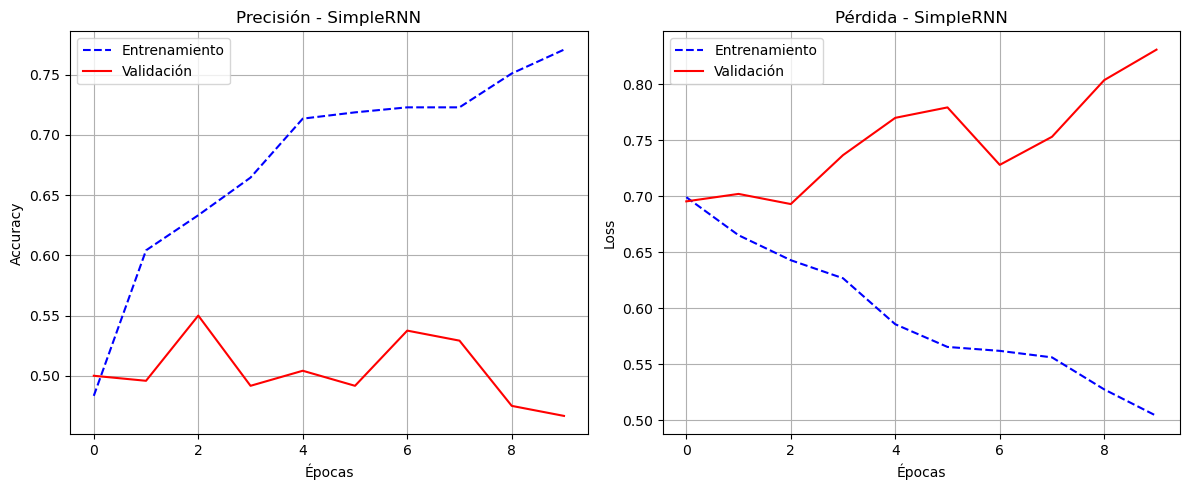

In [96]:
graficar_resultados(history_rnn, "SimpleRNN")

### Modelo LSTM

In [74]:
# 1. Construcción del Modelo LSTM
model_lstm = Sequential([
    # Capa de entrada con la longitud máxima calculada
    Input(shape=(max_len,)),
    
    # Capa Embedding: mask_zero=True es vital para que la LSTM ignore el padding
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True),
    
    # Capa LSTM: Ya no se pone la función de activación
    # 32 unidades para capturar patrones más complejos que la RNN simple.
    LSTM(32),
    
    # Capa de salida: Clasificación binaria (0 o 1)
    Dense(1, activation='sigmoid')
])

# 2. Configuración del Entrenamiento
# Usamos una tasa de aprendizaje ligeramente menor para mayor estabilidad
model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Resumen del modelo
model_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 72, 32)              │           3,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
print("\n" + "="*50 + "\n")

# --- ENTRENAMIENTO DEL MODELO LSTM ---
print(">>> Entrenando LSTM...")

# La LSTM suele requerir más capacidad de cómputo por sus compuertas internas
history_lstm = model_lstm.fit(
    X_train_pad,        # Usamos los mismos datos para que la comparación sea justa
    y_train, 
    epochs=10, 
    batch_size=32, 
    validation_data=(X_test_pad, y_test),
    verbose=1           # Monitoreamos 'loss', 'accuracy', 'val_loss' y 'val_accuracy'
)



>>> Entrenando LSTM...
Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.5021 - loss: 0.6940 - val_accuracy: 0.5208 - val_loss: 0.6930
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5240 - loss: 0.6923 - val_accuracy: 0.4875 - val_loss: 0.6932
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5490 - loss: 0.6905 - val_accuracy: 0.4750 - val_loss: 0.6958
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5542 - loss: 0.6841 - val_accuracy: 0.5708 - val_loss: 0.6874
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9031 - loss: 0.2981 - val_accuracy: 1.0000 - val_loss: 0.0698
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 1.0000 - loss: 0.0347 - val_accuracy: 1.0000 - val_loss: 0.0158
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 1.0000 - loss: 0.0104 - val_accuracy: 1.0000 - val_loss: 0.0071
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 1.0000 - loss: 0.0055 -

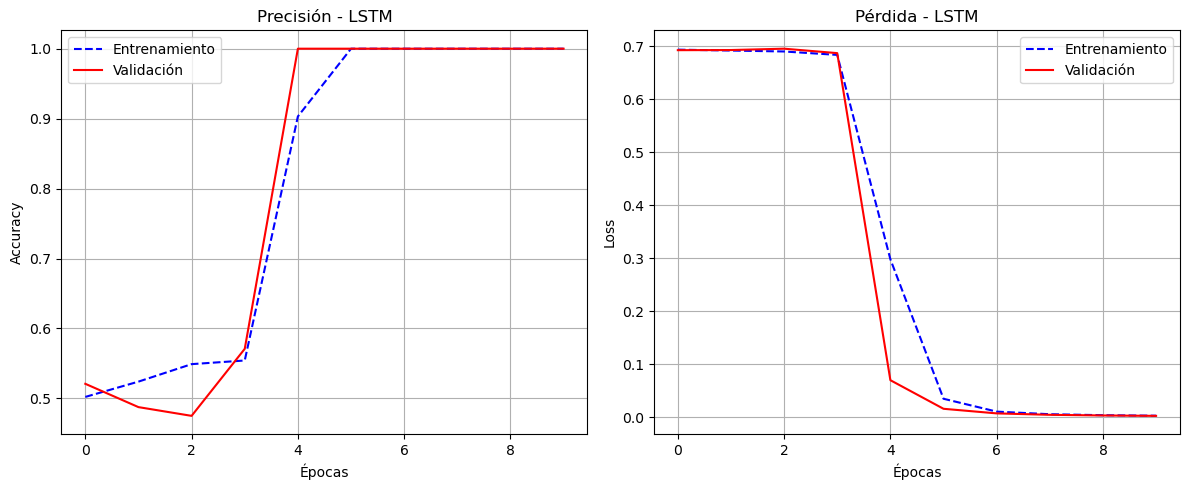

In [94]:
# Graficamos los resultados de ambos modelos
graficar_resultados(history_lstm, "LSTM")

In [106]:
frases_nuevas = [
    "el excelente profesor que durante la extensa clase de inteligencia artificial reviso varios ejemplos "
    "mientras los estudiantes tomaban notas sin parar en sus cuadernos "
    "tratando de mantener el ritmo del temario oficial en todo momento "
    "despues de analizar modelos de memoria con bastante cuidado teorico "
    "concluyo la sesion.",

    "el terrible profesor que durante la extensa clase de inteligencia artificial reviso varios ejemplos "
    "mientras los estudiantes tomaban notas sin parar en sus cuadernos "
    "tratando de mantener el ritmo del temario oficial en todo momento "
    "despues de analizar modelos de memoria con bastante cuidado teorico "
    "concluyo la sesion.",

    "la brillante alumna que mientras comparaba resultados de entrenamiento y validacion con detalle "
    "explicando el comportamiento del gradiente en secuencias largas "
    "revisando varias arquitecturas neuronales con ejemplos comentados "
    "corrigiendo errores frecuentes en la interpretacion de los resultados "
    "se despidio.",

    "la pesima alumna que mientras comparaba resultados de entrenamiento y validacion con detalle "
    "explicando el comportamiento del gradiente en secuencias largas "
    "revisando varias arquitecturas neuronales con ejemplos comentados "
    "corrigiendo errores frecuentes en la interpretacion de los resultados "
    "se despidio."
]

In [110]:

# 2. Preprocesamiento (Tokenización y Padding)
# Usamos el mismo tokenizer y la longitud máxima del entrenamiento
secuencias_nuevas = tokenizer.texts_to_sequences(frases_nuevas)
X_nuevas_pad = pad_sequences(secuencias_nuevas, maxlen=maxlen_final, padding='post')

# 3. Obtención de predicciones (Probabilidades entre 0 y 1)
preds_rnn = model_rnn.predict(X_nuevas_pad)
preds_lstm = model_lstm.predict(X_nuevas_pad)

# 4. Impresión comparativa de resultados
print(f"{'Frase':<45} | {'RNN (Sent)':<15} | {'LSTM (Sent)':<15}")
print("-" * 85)

for i in range(len(frases_nuevas)):
    # Lógica de decisión: > 0.5 es Positivo (1), <= 0.5 es Negativo (0)
    sent_rnn = "Pos ✅" if preds_rnn[i] > 0.5 else "Neg ❌"
    sent_lstm = "Pos ✅" if preds_lstm[i] > 0.5 else "Neg ❌"
    
    # Mostramos la frase recortada y los sentimientos con su probabilidad
    print(f"{frases_nuevas[i][:43]+'...':<45} | {sent_rnn} ({preds_rnn[i][0]:.2f}) | {sent_lstm} ({preds_lstm[i][0]:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Frase                                         | RNN (Sent)      | LSTM (Sent)    
-------------------------------------------------------------------------------------
el excelente profesor que durante la extens... | Neg ❌ (0.48) | Pos ✅ (1.00)
el terrible profesor que durante la extensa... | Neg ❌ (0.36) | Neg ❌ (0.00)
la brillante alumna que mientras comparaba ... | Pos ✅ (0.72) | Pos ✅ (1.00)
la pesima alumna que mientras comparaba res... | Pos ✅ (0.77) | Neg ❌ (0.00)
